# 01. Exploración de datasets

Entrega evaluativa 2 - Análisis de datos

## Dataset 1: Airline Passenger Satisfaction

- **Tipo de dato:** Tabular
- **Fuente:** Secundaria (encuesta de satisfacción de una aerolínea comercial, procesada y publicada en Kaggle por *teejmahal20*)
- **Tamaño en disco:** ~15.23 MB (archivos CSV descomprimidos)
- **Volumen:** 129,880 filas (103,904 train + 25,976 test), 25 columnas
- **Documentación:** Alta — incluye diccionario de variables completo y múltiples análisis de referencia en Kaggle
- **Posibles aplicaciones:** Predicción de satisfacción del cliente (clasificación binaria), segmentación de pasajeros, análisis de factores críticos que impactan la experiencia de vuelo

In [1]:
import os
import warnings
# Configurar nivel de log de kagglehub para evitar mensajes innecesarios
os.environ['KAGGLEHUB_VERBOSITY'] = 'warning'

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

def tamano_carpeta(ruta):
    """Calcula el tamaño total en disco de una carpeta o archivo en megabytes (MB)."""
    if os.path.isfile(ruta):
        return os.path.getsize(ruta) / 1e6
    return sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(ruta) for f in fs) / 1e6


In [2]:
path1 = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")
print("Ruta del dataset:", path1)
print(f"Tamaño en disco: {tamano_carpeta(path1):.2f} MB")


Ruta del dataset: /Users/edwinramirez/.cache/kagglehub/datasets/teejmahal20/airline-passenger-satisfaction/versions/1
Tamaño en disco: 15.23 MB


In [3]:
archivos = os.listdir(path1)
print("Archivos disponibles:", archivos)

# Carga portable usando os.path.join (compatible con Windows, macOS y Linux)
df1_train = pd.read_csv(os.path.join(path1, "train.csv"))
df1_test = pd.read_csv(os.path.join(path1, "test.csv"))

print(f"Train: {df1_train.shape[0]:,} filas x {df1_train.shape[1]} columnas")
print(f"Test:  {df1_test.shape[0]:,} filas x {df1_test.shape[1]} columnas")
print(f"Total combinado: {df1_train.shape[0] + df1_test.shape[0]:,} filas")


Archivos disponibles: ['test.csv', 'train.csv']
Train: 103,904 filas x 25 columnas
Test:  25,976 filas x 25 columnas
Total combinado: 129,880 filas


**Nota:** El dataset viene dividido originalmente en `train.csv` (80%) y `test.csv` (20%). Los unimos para tener el conjunto completo de observaciones disponibles para la exploración.

In [4]:
df1_completo = pd.concat([df1_train, df1_test], ignore_index=True)
print("Dimensiones totales:", df1_completo.shape)
df1_completo.head()


Dimensiones totales: (129880, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [5]:
print("--- Información del dataset (df1_completo.info()) ---")
df1_completo.info()

print("\n--- Tabla resumen de variables, tipos y valores faltantes ---")
resumen_airline = pd.DataFrame({
    "Tipo Dtype": df1_completo.dtypes,
    "No Nulos": df1_completo.notnull().sum(),
    "Faltantes": df1_completo.isnull().sum(),
    "% Faltantes": (df1_completo.isnull().sum() / len(df1_completo) * 100).round(2),
    "Valores Únicos": df1_completo.nunique(),
    "Tipo Variable": [
        "Identificador"
        if c in ["Unnamed: 0", "id"]
        else "Categórica Nominal"
        if df1_completo[c].dtype == "object"
        else "Ordinal (Calificación 0-5)"
        if df1_completo[c].nunique() <= 6 and "delay" not in c.lower() and c not in ["Age", "Flight Distance"]
        else "Numérica Continua"
        for c in df1_completo.columns
    ]
})
display(resumen_airline)


--- Información del dataset (df1_completo.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null

,Tipo Dtype,No Nulos,Faltantes,% Faltantes,Valores Únicos,Tipo Variable
Unnamed: 0,int64,129880,0,0.0,103904,Identificador
id,int64,129880,0,0.0,129880,Identificador
Gender,object,129880,0,0.0,2,Categórica Nominal
Customer Type,object,129880,0,0.0,2,Categórica Nominal
Age,int64,129880,0,0.0,75,Numérica Continua
Type of Travel,object,129880,0,0.0,2,Categórica Nominal
Class,object,129880,0,0.0,3,Categórica Nominal
Flight Distance,int64,129880,0,0.0,3821,Numérica Continua
Inflight wifi service,int64,129880,0,0.0,6,Ordinal (Calificación 0-5)
Departure/Arrival time convenient,int64,129880,0,0.0,6,Ordinal (Calificación 0-5)


## Dataset 2: Chest X-Ray Images (Pneumonia)

- **Tipo de dato:** Imágenes (visión artificial)
- **Fuente:** Secundaria (radiografías clínicas pediátricas del Guangzhou Women and Children’s Medical Center, publicadas por *paultimothymooney*)
- **Tamaño en disco:** ~2,483.92 MB (~2.48 GB)
- **Volumen:** ~5,856 imágenes distribuidas en carpetas `train`, `test` y `val`
- **Documentación:** Alta — ampliamente citado en publicaciones biomédicas y benchmarks de Deep Learning
- **Posibles aplicaciones:** Clasificación binaria (Neumonía vs. Normal), detección y soporte diagnóstico automatizado en salud

In [6]:
path2 = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Ruta del dataset:", path2)
print(f"Tamaño en disco: {tamano_carpeta(path2):.2f} MB ({tamano_carpeta(path2)/1024:.2f} GB)")


Ruta del dataset: /Users/edwinramirez/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
Tamaño en disco: 2483.92 MB (2.43 GB)


In [7]:
ruta_real = os.path.join(path2, "chest_xray", "chest_xray")

conteo_splits = []
for split in ["train", "test", "val"]:
    for clase in ["NORMAL", "PNEUMONIA"]:
        carpeta = os.path.join(ruta_real, split, clase)
        n = len([f for f in os.listdir(carpeta) if f.lower().endswith((".jpeg", ".jpg", ".png"))])
        conteo_splits.append({"Split": split, "Clase": clase, "Imágenes": n})

df_conteo = pd.DataFrame(conteo_splits)
df_pivot = df_conteo.pivot(index="Split", columns="Clase", values="Imágenes")
df_pivot["Total"] = df_pivot["NORMAL"] + df_pivot["PNEUMONIA"]
df_pivot["% Neumonía"] = (df_pivot["PNEUMONIA"] / df_pivot["Total"] * 100).round(2)
df_pivot["Ratio (Pneu/Norm)"] = (df_pivot["PNEUMONIA"] / df_pivot["NORMAL"]).round(2)

print("--- Distribución de imágenes por split y clase ---")
display(df_pivot)

print("\nObservaciones críticas de distribución:")
print(f"1. Desbalance en train: {df_pivot.loc['train', 'PNEUMONIA']} neumonía vs {df_pivot.loc['train', 'NORMAL']} normal "
      f"(≈{df_pivot.loc['train', 'Ratio (Pneu/Norm)']:.2f} veces más neumonía, equivalente al {df_pivot.loc['train', '% Neumonía']}% de las imágenes).")
print(f"2. Carpeta val: Solo contiene {df_pivot.loc['val', 'Total']} imágenes en total ({df_pivot.loc['val', 'NORMAL']} normal y {df_pivot.loc['val', 'PNEUMONIA']} neumonía), "
      f"lo que resulta insuficiente como conjunto de validación representativo sin una re-partición adecuada.")


--- Distribución de imágenes por split y clase ---


Clase,NORMAL,PNEUMONIA,Total,% Neumonía,Ratio (Pneu/Norm)
Split,,,,,
test,234,390,624,62.50,1.67
train,1341,3875,5216,74.29,2.89
val,8,8,16,50.00,1.00



Observaciones críticas de distribución:
1. Desbalance en train: 3875 neumonía vs 1341 normal (≈2.89 veces más neumonía, equivalente al 74.29% de las imágenes).
2. Carpeta val: Solo contiene 16 imágenes en total (8 normal y 8 neumonía), lo que resulta insuficiente como conjunto de validación representativo sin una re-partición adecuada.


In [8]:
# Inspección técnica de dimensiones y modo de color en una muestra de imágenes
muestra_info = []
for clase in ["NORMAL", "PNEUMONIA"]:
    carpeta = os.path.join(ruta_real, "train", clase)
    archivos_clase = sorted([f for f in os.listdir(carpeta) if f.lower().endswith((".jpeg", ".jpg", ".png"))])
    for f in archivos_clase[:5]:
        ruta_img = os.path.join(carpeta, f)
        with Image.open(ruta_img) as img:
            muestra_info.append({
                "Clase": clase,
                "Archivo": f,
                "Ancho (px)": img.width,
                "Alto (px)": img.height,
                "Aspect Ratio (W/H)": round(img.width / img.height, 2),
                "Modo PIL": img.mode,
                "Canales": len(img.getbands()),
                "Tipo de Color": "Escala de grises (1 canal)" if img.mode in ['L', '1'] else f"Multicanal ({img.mode})"
            })

df_muestra_img = pd.DataFrame(muestra_info)
print("--- Muestra de características técnicas de imágenes (resolución y canales) ---")
display(df_muestra_img)

print(f"Rango de anchos en la muestra: {df_muestra_img['Ancho (px)'].min()} px a {df_muestra_img['Ancho (px)'].max()} px")
print(f"Rango de altos en la muestra:  {df_muestra_img['Alto (px)'].min()} px a {df_muestra_img['Alto (px)'].max()} px")
print("Hallazgo: Las imágenes son en escala de grises (modo 'L', 1 canal de intensidad) y sus resoluciones varían ampliamente, requiriendo reescalado previo.")


--- Muestra de características técnicas de imágenes (resolución y canales) ---


,Clase,Archivo,Ancho (px),Alto (px),Aspect Ratio (W/H),Modo PIL,Canales,Tipo de Color
0,NORMAL,IM-0115-0001.jpeg,2090,1858,1.12,L,1,Escala de grises (1 canal)
1,NORMAL,IM-0117-0001.jpeg,1422,1152,1.23,L,1,Escala de grises (1 canal)
2,NORMAL,IM-0119-0001.jpeg,1810,1434,1.26,L,1,Escala de grises (1 canal)
3,NORMAL,IM-0122-0001.jpeg,1618,1279,1.27,L,1,Escala de grises (1 canal)
4,NORMAL,IM-0125-0001.jpeg,1600,1125,1.42,L,1,Escala de grises (1 canal)
5,PNEUMONIA,person1000_bacteria_2931.jpeg,1152,760,1.52,L,1,Escala de grises (1 canal)
6,PNEUMONIA,person1000_virus_1681.jpeg,1072,768,1.40,L,1,Escala de grises (1 canal)
7,PNEUMONIA,person1001_bacteria_2932.jpeg,1244,863,1.44,L,1,Escala de grises (1 canal)
8,PNEUMONIA,person1002_bacteria_2933.jpeg,1242,940,1.32,L,1,Escala de grises (1 canal)
9,PNEUMONIA,person1003_bacteria_2934.jpeg,1488,1280,1.16,L,1,Escala de grises (1 canal)


Rango de anchos en la muestra: 1072 px a 2090 px
Rango de altos en la muestra:  760 px a 1858 px
Hallazgo: Las imágenes son en escala de grises (modo 'L', 1 canal de intensidad) y sus resoluciones varían ampliamente, requiriendo reescalado previo.


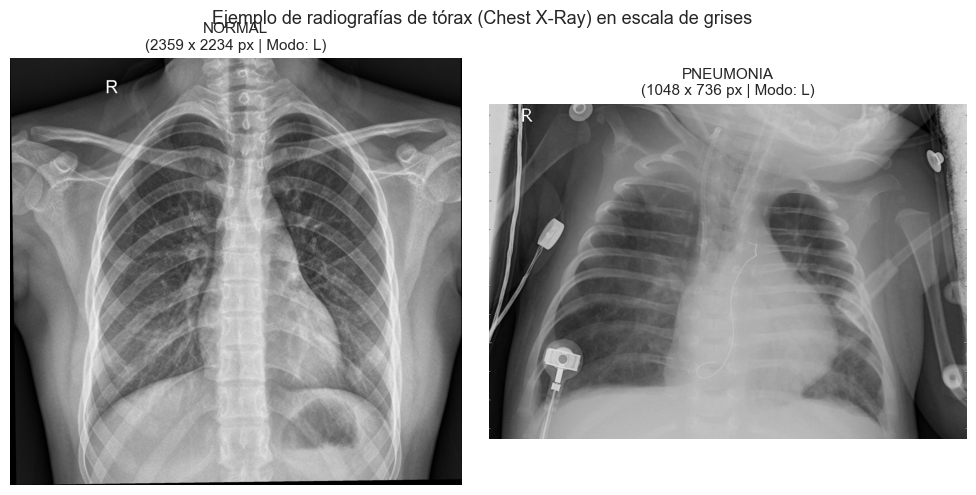

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, clase in zip(axes, ["NORMAL", "PNEUMONIA"]):
    carpeta = os.path.join(ruta_real, "train", clase)
    imagenes_validas = [f for f in os.listdir(carpeta) if f.lower().endswith((".jpeg", ".jpg", ".png"))]
    primera_imagen = imagenes_validas[0]
    img = Image.open(os.path.join(carpeta, primera_imagen))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{clase}\n({img.width} x {img.height} px | Modo: {img.mode})", fontsize=11)
    ax.axis('off')
plt.suptitle("Ejemplo de radiografías de tórax (Chest X-Ray) en escala de grises", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()


## Dataset 3: IMDB Movie Reviews (análisis de sentimiento)

- **Tipo de dato:** Texto no estructurado (Procesamiento de Lenguaje Natural - PLN)
- **Fuente:** Secundaria (reseñas públicas de usuarios en IMDB, recopiladas y publicadas por Maas et al., 2011)
- **Tamaño en disco:** ~66.21 MB (archivo CSV)
- **Volumen:** 50,000 reseñas etiquetadas (25,000 positivas / 25,000 negativas)
- **Documentación:** Alta — es un benchmark estándar de la literatura científica de PLN
- **Posibles aplicaciones:** Clasificación de polaridad de sentimiento, análisis de opinión, entrenamiento de modelos de PLN y embeddings

In [10]:
path3 = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Ruta del dataset:", path3)
print(f"Tamaño en disco: {tamano_carpeta(path3):.2f} MB")


Ruta del dataset: /Users/edwinramirez/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1
Tamaño en disco: 66.21 MB


In [11]:
archivos3 = os.listdir(path3)
print("Archivos disponibles:", archivos3)

# Carga portable usando os.path.join
df3 = pd.read_csv(os.path.join(path3, "IMDB Dataset.csv"))
print(f"Dimensiones: {df3.shape[0]:,} reseñas x {df3.shape[1]} columnas")
df3.head()


Archivos disponibles: ['IMDB Dataset.csv']


Dimensiones: 50,000 reseñas x 2 columnas


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


--- Conteo por clase (sentimiento) ---
- Positive: 25,000 reseñas (50.0%)
- Negative: 25,000 reseñas (50.0%)



--- Estadísticas descriptivas de longitud (palabras por reseña) ---
count    50000.00
mean       231.16
std        171.34
min          4.00
25%        126.00
50%        173.00
75%        280.00
max       2470.00
Name: conteo_palabras, dtype: float64


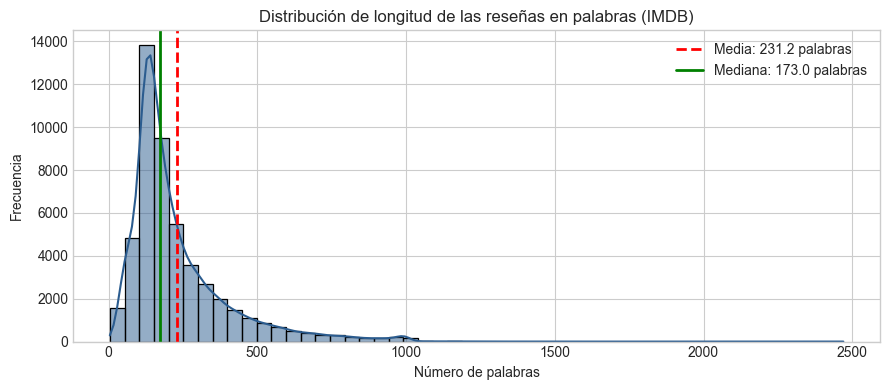

--- Presencia de etiquetas HTML y ruido textual ---
Reseñas con etiquetas HTML: 29,202 de 50,000 (58.4%)
Reseñas que contienen específicamente '<br />': 29,200 (58.4%)

Ejemplo de reseña con etiquetas HTML antes de limpiar:
"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right f..."


In [12]:
# 1. Conteo por clase
conteo_clases = df3["sentiment"].value_counts()
print("--- Conteo por clase (sentimiento) ---")
for sent, cnt in conteo_clases.items():
    print(f"- {sent.capitalize()}: {cnt:,} reseñas ({cnt/len(df3)*100:.1f}%)")

# 2. Longitud promedio en palabras y estadísticas
df3["conteo_palabras"] = df3["review"].apply(lambda x: len(x.split()))
print("\n--- Estadísticas descriptivas de longitud (palabras por reseña) ---")
print(df3["conteo_palabras"].describe().round(2))

# Histograma de longitud de palabras
fig, ax = plt.subplots(figsize=(9, 4))
media_p = df3["conteo_palabras"].mean()
mediana_p = df3["conteo_palabras"].median()
sns.histplot(df3["conteo_palabras"], bins=50, kde=True, color="#2b5c8f", ax=ax)
ax.axvline(media_p, color="red", linestyle="--", linewidth=2, label=f"Media: {media_p:.1f} palabras")
ax.axvline(mediana_p, color="green", linestyle="-", linewidth=2, label=f"Mediana: {mediana_p:.1f} palabras")
ax.set_title("Distribución de longitud de las reseñas en palabras (IMDB)", fontsize=12)
ax.set_xlabel("Número de palabras")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 3. Detección de etiquetas HTML (<br />)
con_html = df3["review"].str.contains(r"<[^>]+>", regex=True).sum()
con_br = df3["review"].str.contains("<br />", regex=False).sum()
print("--- Presencia de etiquetas HTML y ruido textual ---")
print(f"Reseñas con etiquetas HTML: {con_html:,} de {len(df3):,} ({con_html/len(df3)*100:.1f}%)")
print(f"Reseñas que contienen específicamente '<br />': {con_br:,} ({con_br/len(df3)*100:.1f}%)")

print("\nEjemplo de reseña con etiquetas HTML antes de limpiar:")
ejemplo_html = df3[df3["review"].str.contains("<br />")]["review"].iloc[0][:280]
print(f'"{ejemplo_html}..."')


> **Comentario sobre preprocesamiento en IMDB:** Más del 58% de las reseñas contienen etiquetas HTML como `<br />` producto del raspado (*web scraping*) de la plataforma web. Antes de utilizar este texto en cualquier algoritmo de aprendizaje automático, es estrictamente necesario aplicar una etapa intensiva de preprocesamiento de PLN: eliminación de etiquetas HTML (mediante expresiones regulares o parsers como BeautifulSoup), conversión a minúsculas, eliminación de signos de puntuación, filtrado de *stopwords*, y vectorización (TF-IDF o *embeddings*).

## Tabla comparativa de criterios de selección

Para garantizar una elección fundamentada, objetiva y alineada con los requisitos metodológicos del curso, evaluamos los tres datasets bajo cuatro criterios clave con una escala del **1 al 5** (donde 1 representa una deficiencia o dificultad significativa y 5 representa una idoneidad óptima):

| Criterio | Airline | Chest X-Ray | IMDB |
|---|:---:|:---:|:---:|
| Completitud | 5 | 4 | 5 |
| Relevancia para el curso (EDA, PCA) | 5 | 3 | 2 |
| Documentación | 5 | 4 | 5 |
| Manejabilidad | 5 | 2 | 3 |
| **Total** | **20** | **13** | **15** |

### Justificación detallada de las puntuaciones:

- **Completitud:**
  - *Airline (5/5):* 129,880 registros completos con 25 variables; únicamente una columna presenta faltantes (393 valores, correspondiente al 0.30% en `Arrival Delay`), ideal para ilustrar técnicas de imputación sin perder potencia muestral.
  - *Chest X-Ray (4/5):* 5,856 imágenes con etiquetas diagnósticas, pero la carpeta `val` tiene únicamente 16 imágenes (8 normales y 8 neumonía), lo que constituye una limitación severa para evaluar modelos sin re-particionar.
  - *IMDB (5/5):* 50,000 registros completos, perfectamente balanceados (25,000 positivos y 25,000 negativos).

- **Relevancia para el curso (EDA, PCA, Pruebas Estadísticas):**
  - *Airline (5/5):* Máxima pertinencia. Integra variables cuantitativas continuas (edad, distancia de vuelo, retrasos), variables cualitativas nominales (género, clase, tipo de viaje) y 14 escalas ordinales de satisfacción (1 al 5). Es el escenario ideal para practicar EDA multivariado, pruebas de hipótesis ($\chi^2$, Mann-Whitney), correlaciones (Pearson vs. Spearman), codificación categórica y reducción de dimensionalidad con **PCA y t-SNE** altamente interpretables.
  - *Chest X-Ray (3/5):* Requiere técnicas de visión computacional y Redes Convolucionales (CNNs). Aplicar PCA sobre píxeles crudos sin alineación anatómica produce componentes poco interpretables estadísticamente para el propósito del curso.
  - *IMDB (2/5):* Exige procesamiento de texto no estructurado y matrices dispersas de alta dimensionalidad (TF-IDF o embeddings), alejándose del enfoque de análisis exploratorio multivariado tradicional y PCA sobre variables continuas del curso.

- **Documentación:**
  - *Airline (5/5):* Diccionario detallado de cada una de las 25 variables y abundantes casos de estudio en Kaggle.
  - *Chest X-Ray (4/5):* Respaldado por publicaciones científicas médicas, pero carece de metadatos clínicos de los pacientes.
  - *IMDB (5/5):* Benchmark estándar de la literatura científica internacional, exhaustivamente documentado.

- **Manejabilidad:**
  - *Airline (5/5):* Ocupa ~15.2 MB en disco. Carga instantáneamente en Pandas y permite operaciones estadísticas vectorizadas inmediatas sin requerir GPU ni sobrecargar la memoria.
  - *Chest X-Ray (2/5):* Ocupa ~2.48 GB en disco; leer, decodificar y redimensionar miles de imágenes de resolución heterogénea exige un costo computacional y de memoria considerable.
  - *IMDB (3/5):* Ocupa ~66.2 MB en disco; requiere una fase previa de limpieza de cadenas (etiquetas HTML `<br />`, signos, tokenización) antes de poder utilizarse.

## Justificación de la elección: Airline Passenger Satisfaction

Se selecciona este dataset como base para las Fases 2 y 3 del proyecto por las siguientes razones:

- **Completitud:** 129,880 registros con 25 variables, tamaño suficiente para un análisis robusto sin ser inmanejable.
- **Relevancia:** combina variables numéricas (edad, distancia de vuelo, tiempos de demora) y categóricas (género, tipo de cliente, clase de viaje) — ideal para aplicar EDA multivariado, codificación de categóricas, escalado y PCA con sentido interpretable.
- **Documentación:** dataset ampliamente documentado en Kaggle, con diccionario de variables claro.
- **Manejabilidad:** a diferencia de los datasets de imágenes y texto (que requieren procesamiento especializado como visión computacional o NLP), este dataset tabular permite aplicar directamente todas varias de las técnicas que hemos visto.

Los datasets de imágenes (Chest X-Ray) y texto (IMDB) se documentaron como parte de la exploración inicial, pero se descartan para el análisis profundo por requerir técnicas de preprocesamiento mas especializadas.